<a href="https://colab.research.google.com/github/nouramar228-cyber/intermediate-ml-practice-solutions/blob/main/PCA_to_Visualize_Clusters_(Practice).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assignment:**
When clusters are made from more than two features, it is very difficult to visualize the resulting clusters. While 3D plots can be made with Plotly, visualizing more than three features is nearly impossible.

An interesting solution to this is to use PCA to reduce the dimensionality for the purpose of visualizing the clusters.

In this assignment, you will combine PCA and clustering to a credit card customer data set and visualize those clusters in both two-dimensional and three-dimensional scatter plots.

Specifically, you will:

Load the data ( [found here](https://drive.google.com/file/d/1IlQ_OZ4f_S5mdkGXumJNYEWaA6ioeDrr/view))
Perform basic data cleaning
Drop "Unnamed 0" and "Customer Id"
Fill in missing values
Use the remaining eight features of the dataset to perform KMeans clustering.
Be sure to scale the data prior to clustering.
Determine a value for K (number of clusters) using the elbow method and/or silhouette score.
Use PCA to define two principal components.
Visualize the 2 PCs using a scatter plot where points are colored by cluster. While the features (PCs) will no longer be meaningful, you can see how well the model clustered the data.
Use PCA to define three principal components.
Visualize the 3 PCs using Plotly's 3d scatterplot, where points are colored by cluster

**1. Import Necessary Libraries**



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score



**2. Load Data**

In [ ]:
fpath = '/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/05-IntermediateML/Week18/Data/cust_seg.csv'
df =pd.read_csv(fpath)
df.head()

,Unnamed: 0,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
0,0,1,41,2,6,19,0.124,1.073,0.0,6.3
1,1,2,47,1,26,100,4.582,8.218,0.0,12.8
2,2,3,33,2,10,57,6.111,5.802,1.0,20.9
3,3,4,29,2,4,19,0.681,0.516,0.0,6.3
4,4,5,47,1,31,253,9.308,8.908,0.0,7.2


**3. Drop Unnecessary Columns**

In [ ]:
df.drop(columns=['Unnamed: 0','Customer Id'], inplace =True)
df

,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
0,41,2,6,19,0.124,1.073,0.0,6.3
1,47,1,26,100,4.582,8.218,0.0,12.8
2,33,2,10,57,6.111,5.802,1.0,20.9
3,29,2,4,19,0.681,0.516,0.0,6.3
4,47,1,31,253,9.308,8.908,0.0,7.2
...,...,...,...,...,...,...,...,...
845,27,1,5,26,0.548,1.220,NaN,6.8
846,28,2,7,34,0.359,2.021,0.0,7.0
847,25,4,0,18,2.802,3.210,1.0,33.4
848,32,1,12,28,0.116,0.696,0.0,2.9


** 4. EDA and Cleaning**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              850 non-null    int64  
 1   Edu              850 non-null    int64  
 2   Years Employed   850 non-null    int64  
 3   Income           850 non-null    int64  
 4   Card Debt        850 non-null    float64
 5   Other Debt       850 non-null    float64
 6   Defaulted        700 non-null    float64
 7   DebtIncomeRatio  850 non-null    float64
dtypes: float64(4), int64(4)
memory usage: 53.3 KB


In [ ]:
#check missing values
df.isna().sum()

,0
Age,0
Edu,0
Years Employed,0
Income,0
Card Debt,0
Other Debt,0
Defaulted,150
DebtIncomeRatio,0


In [ ]:
mode = df['Defaulted'].mode()[0]
df['Defaulted'].fillna(mode, inplace=True)
df.isna().sum()


/tmp/ipykernel_2383/2643972477.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Defaulted'].fillna(mode, inplace=True)


,0
Age,0
Edu,0
Years Employed,0
Income,0
Card Debt,0
Other Debt,0
Defaulted,0
DebtIncomeRatio,0


**5. Scale Data**

In [ ]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
df_scaled


array([[ 0.74291541,  0.31212243, -0.37878978, ..., -0.59048916,
        -0.52379654, -0.57652509],
       [ 1.48949049, -0.76634938,  2.5737211 , ...,  1.51296181,
        -0.52379654,  0.39138677],
       [-0.25251804,  0.31212243,  0.2117124 , ...,  0.80170393,
         1.90913822,  1.59755385],
       ...,
       [-1.24795149,  2.46906604, -1.26454304, ...,  0.03863257,
         1.90913822,  3.45892281],
       [-0.37694723, -0.76634938,  0.50696349, ..., -0.70147601,
        -0.52379654, -1.08281745],
       [ 2.1116364 , -0.76634938,  1.09746566, ...,  0.16463355,
        -0.52379654, -0.2340332 ]])

**6. Tune a KMeans Model and Cluster the Scaled Data**

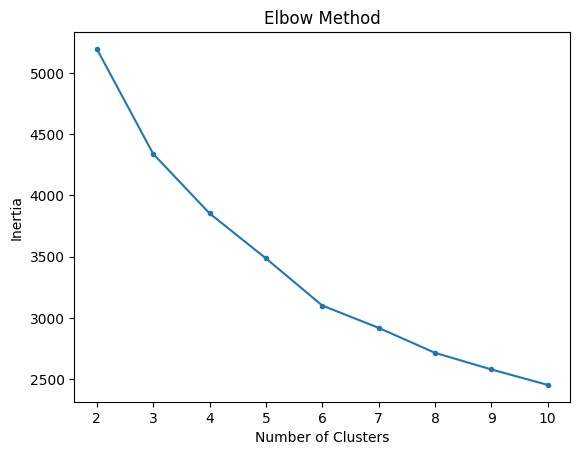

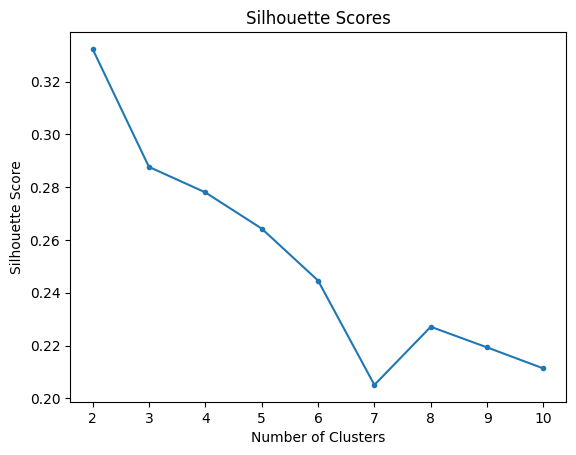

In [ ]:
inertias = []
silhouette_scores = []
for i in range(2,11):
  kmeans = KMeans(n_clusters= i , n_init = "auto", random_state= 42)
  kmeans.fit(df_scaled)
  inertias.append(kmeans.inertia_)
  silhouette_scores.append(silhouette_score(df_scaled,kmeans.labels_))

plt.plot(range(2,11), inertias, marker = '.')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

plt.plot(range(2,11) , silhouette_scores, marker = '.')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')
plt.show()

In [ ]:

kmeans_model = KMeans(n_clusters=2)

kmeans_model.fit(df_scaled)

KMeans(n_clusters=2)

**7. Transform the Scaled Data with PCA**

In [ ]:
pca = PCA()
pca_df = pca.fit_transform(df_scaled)

 **8. Plot the Clusters**

The x axis should be the first principal component, you can extract this from the PCA array with pca_data[:,0]

The y axis should be the second principal component, you can extract this from the PCA array with pca_data[:,1]

The c argument should be the labels from the kmeans model.

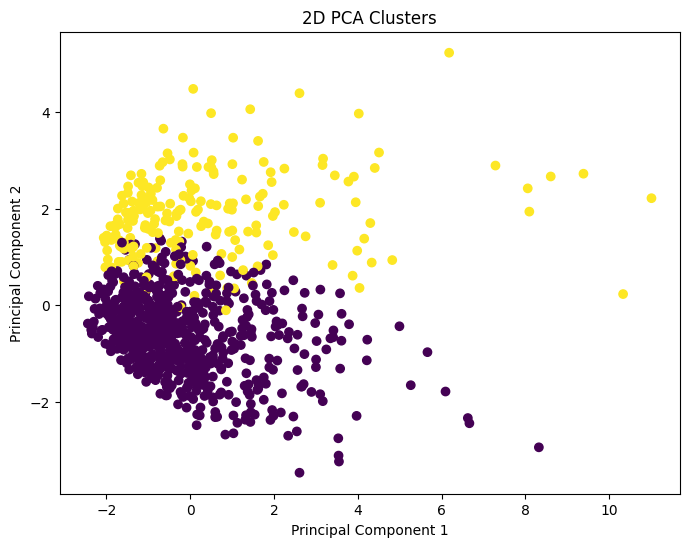

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(pca_df[:,0], pca_df[:,1], c=kmeans_model.labels_)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('2D PCA Clusters')
plt.show()

**9. Plot 3 components with Plotly Express**

x, y, and z should be the first 3 components and color should be the KMeans model clusters.

In [ ]:
import plotly.express as px
px.scatter_3d(x=pca_df[:,0], y=pca_df[:,1], z=pca_df[:,2], color=kmeans_model.labels_)

